# Zero-shot XGBoost — Binary Classification Benchmark

Exhaustive comparison across five ADMET binary classification datasets from the
[Therapeutics Data Commons](https://tdcommons.ai/).

| Dataset | Task | n | Imbalance |
|---|---|---|---|
| BBB_Martins | Blood-brain barrier penetration | 2,050 | 3.3 : 1 |
| Pgp_Broccatelli | P-glycoprotein inhibition | 1,218 | 1.1 : 1 |
| hERG | hERG cardiotoxicity | 655 | 2.2 : 1 |
| HIA_Hou | Human intestinal absorption | 578 | 6.4 : 1 |
| AMES | Ames mutagenicity | 7,278 | 1.2 : 1 |

**Models compared:**
- `ZS-XGBoost (portfolio)` — trains 5 preset configurations on a validation split and picks the best:
  `internal` · `default` · `flaml` · `autogluon` · `rf`
- `ZS-XGBoost (default)` — XGBoost defaults with early stopping (`portfolio=False`); the no-tuning baseline
- `Default XGBoost` — plain `XGBClassifier` with `scale_pos_weight` for imbalance
- `Default RF` — `RandomForestClassifier` with `class_weight='balanced'`
- `Logistic Reg.` — L2 logistic regression with `class_weight='balanced'`

**Features:** 1 024-bit ECFP4 Morgan fingerprints computed with RDKit.

**Evaluation:** Stratified 80/20 test split, ROC-AUC and PR-AUC on the held-out test set.

In [1]:
# Install / upgrade from the local source tree (run once after pulling changes)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "..", "-q"])

0

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from zsxgboost import ZeroShotXGBClassifier

RDLogger.DisableLog("rdApp.*")   # suppress RDKit SMILES-parsing warnings

_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


def smiles_to_ecfp4(smiles_list, n_bits=1024):
    gen = _morgan_gen if n_bits == 1024 else rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
        else:
            fps.append(gen.GetFingerprintAsNumPy(mol).astype(np.uint8))
    return np.vstack(fps)


def load_dataset(path, test_size=0.2, random_state=42):
    df = pd.read_csv(path, sep='\t')
    df = df.dropna(subset=['Drug', 'Y'])
    df['Y'] = df['Y'].astype(int)
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df['Y'], random_state=random_state
    )
    X_train = smiles_to_ecfp4(train_df['Drug'])
    X_test  = smiles_to_ecfp4(test_df['Drug'])
    return X_train, X_test, train_df['Y'].values, test_df['Y'].values


print("Imports OK")

Imports OK


In [3]:
DATA_DIR = "../data"

DATASETS = [
    {"name": "BBB_Martins",     "file": f"{DATA_DIR}/bbb_martins.tab"},
    {"name": "Pgp_Broccatelli", "file": f"{DATA_DIR}/pgp_broccatelli.tab"},
    {"name": "hERG",            "file": f"{DATA_DIR}/herg.tab"},
    {"name": "HIA_Hou",         "file": f"{DATA_DIR}/hia_hou.tab"},
    {"name": "AMES",            "file": f"{DATA_DIR}/ames.tab"},
]

# Column orders used by all summary / ranking / bar-chart cells
ds_order  = [ds["name"] for ds in DATASETS]
col_order = ["ZS-XGBoost (portfolio)", "ZS-XGBoost (default)",
             "Default XGBoost", "Default RF", "Logistic Reg."]

print(f"Datasets: {ds_order}")

Datasets: ['BBB_Martins', 'Pgp_Broccatelli', 'hERG', 'HIA_Hou', 'AMES']


## 2. Run benchmark

In [4]:
# Storage for results, curves, profiles, and portfolio info
all_results          = []
all_curves           = {}
all_profiles         = {}
all_preset_winners   = {}   # dataset → winning preset name
all_portfolio_scores = {}   # dataset → {preset: val_score}

MODEL_STYLES = {
    "ZS-XGBoost (portfolio)": dict(lw=2.5, linestyle="-",   color="#e41a1c"),
    "ZS-XGBoost (default)":   dict(lw=2.0, linestyle="--",  color="#ff7f00"),
    "Default XGBoost":        dict(lw=1.5, linestyle="-.",  color="#377eb8"),
    "Default RF":             dict(lw=1.5, linestyle="--",  color="#4daf4a"),
    "Logistic Reg.":          dict(lw=1.5, linestyle=":",   color="#984ea3"),
}

for ds in DATASETS:
    name = ds["name"]
    print(f"\n{'='*60}\nDataset: {name}\n{'='*60}")

    X_train, X_test, y_train, y_test = load_dataset(ds["file"])
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    imbalance_ratio = neg / pos
    baseline_pr = y_test.mean()
    print(f"  Train n={len(y_train):,}  Test n={len(y_test):,}  imbalance={imbalance_ratio:.2f}")

    all_curves[name] = {}

    models = {
        "ZS-XGBoost (portfolio)": ZeroShotXGBClassifier(verbose=False, portfolio=True),
        "ZS-XGBoost (default)":   ZeroShotXGBClassifier(verbose=False, portfolio=False),
        "Default XGBoost":        XGBClassifier(scale_pos_weight=imbalance_ratio,
                                                eval_metric="auc", verbosity=0, random_state=42),
        "Default RF":             RandomForestClassifier(class_weight="balanced", random_state=42),
        "Logistic Reg.":          LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_prob = (model.predict_proba(X_test)[:, 1]
                  if hasattr(model, 'predict_proba')
                  else model.decision_function(X_test))

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        fpr, tpr, _  = roc_curve(y_test, y_prob)
        prec, rec, _ = precision_recall_curve(y_test, y_prob)

        all_results.append({"Dataset": name, "Model": model_name,
                             "ROC-AUC": roc_auc, "PR-AUC": pr_auc})
        all_curves[name][model_name] = dict(fpr=fpr, tpr=tpr, prec=prec, rec=rec,
                                            baseline_pr=baseline_pr)

        if model_name == "ZS-XGBoost (portfolio)":
            all_profiles[name]         = model.profile_
            all_preset_winners[name]   = model.preset_name_
            all_portfolio_scores[name] = model.portfolio_scores_
            print(f"  {model_name:26s}  ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}"
                  f"  → preset: {model.preset_name_}")
        else:
            print(f"  {model_name:26s}  ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}")

results_df = pd.DataFrame(all_results)
print("\nBenchmark complete.")


Dataset: BBB_Martins


  Train n=1,631  Test n=408  imbalance=0.31


  ZS-XGBoost (portfolio)      ROC-AUC=0.9293  PR-AUC=0.9734  → preset: default


  ZS-XGBoost (default)        ROC-AUC=0.9293  PR-AUC=0.9734


  Default XGBoost             ROC-AUC=0.9266  PR-AUC=0.9710


...

  ZS-XGBoost (portfolio)      ROC-AUC=0.8829  PR-AUC=0.8889  → preset: default


  ZS-XGBoost (default)        ROC-AUC=0.8829  PR-AUC=0.8889


  Default XGBoost             ROC-AUC=0.8805  PR-AUC=0.8857


  Default RF                  ROC-AUC=0.8962  PR-AUC=0.9002


  Logistic Reg.               ROC-AUC=0.8318  PR-AUC=0.8339

Benchmark complete.


## 3. Portfolio selection breakdown

Which of the five preset configurations won on each dataset?

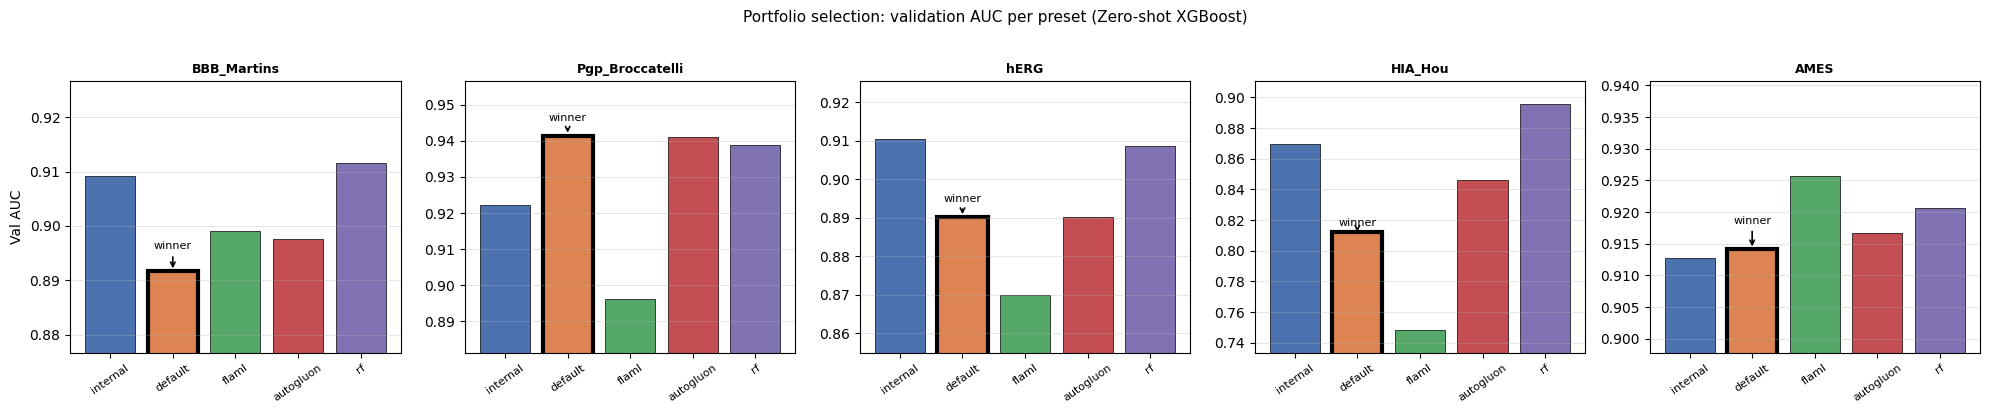

,Winner,internal,default,flaml,autogluon,rf
Dataset,,,,,,
BBB_Martins,default,0.909100,0.891700,0.899100,0.897600,0.911600
Pgp_Broccatelli,default,0.922200,0.941500,0.896300,0.941100,0.939000
hERG,default,0.910500,0.890200,0.869900,0.890200,0.908800
HIA_Hou,default,0.869400,0.812400,0.748500,0.846000,0.895500
AMES,default,0.912800,0.914100,0.925600,0.916600,0.920700


In [5]:
PRESET_ORDER  = ["internal", "default", "flaml", "autogluon", "rf"]
PRESET_COLORS = {
    "internal":  "#4C72B0",
    "default":   "#DD8452",
    "flaml":     "#55A868",
    "autogluon": "#C44E52",
    "rf":        "#8172B3",
}

n_ds = len(DATASETS)
fig, axes = plt.subplots(1, n_ds, figsize=(4.0 * n_ds, 4.0), sharey=False)
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, DATASETS):
    name   = ds["name"]
    scores = all_portfolio_scores[name]
    winner = all_preset_winners[name]

    presets = [p for p in PRESET_ORDER if p in scores]
    vals    = [scores[p] for p in presets]
    lws     = [3 if p == winner else 0.5 for p in presets]
    colors  = [PRESET_COLORS[p] for p in presets]

    ax.bar(presets, vals, color=colors, edgecolor="black", linewidth=lws)

    wi = presets.index(winner)
    ax.annotate("winner", xy=(wi, vals[wi]), xytext=(wi, vals[wi] + 0.004),
                ha="center", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

    ymin = max(0.0, min(vals) - 0.015)
    ymax = min(1.0, max(vals) + 0.015)
    ax.set_ylim(ymin, ymax)
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_ylabel("Val AUC" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Portfolio selection: validation AUC per preset (Zero-shot XGBoost)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("../results/portfolio_selection.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabular summary
rows = []
for ds in DATASETS:
    name   = ds["name"]
    scores = all_portfolio_scores[name]
    winner = all_preset_winners[name]
    row    = {"Dataset": name, "Winner": winner}
    row.update({p: round(scores.get(p, float("nan")), 4) for p in PRESET_ORDER})
    rows.append(row)

portfolio_df = pd.DataFrame(rows).set_index("Dataset")

def _hl(row):
    w = row["Winner"]
    return ["background-color:#d4edda;font-weight:bold" if c == w else "" for c in row.index]

portfolio_df.style.apply(_hl, axis=1)

## 4. ROC and PR curves per dataset

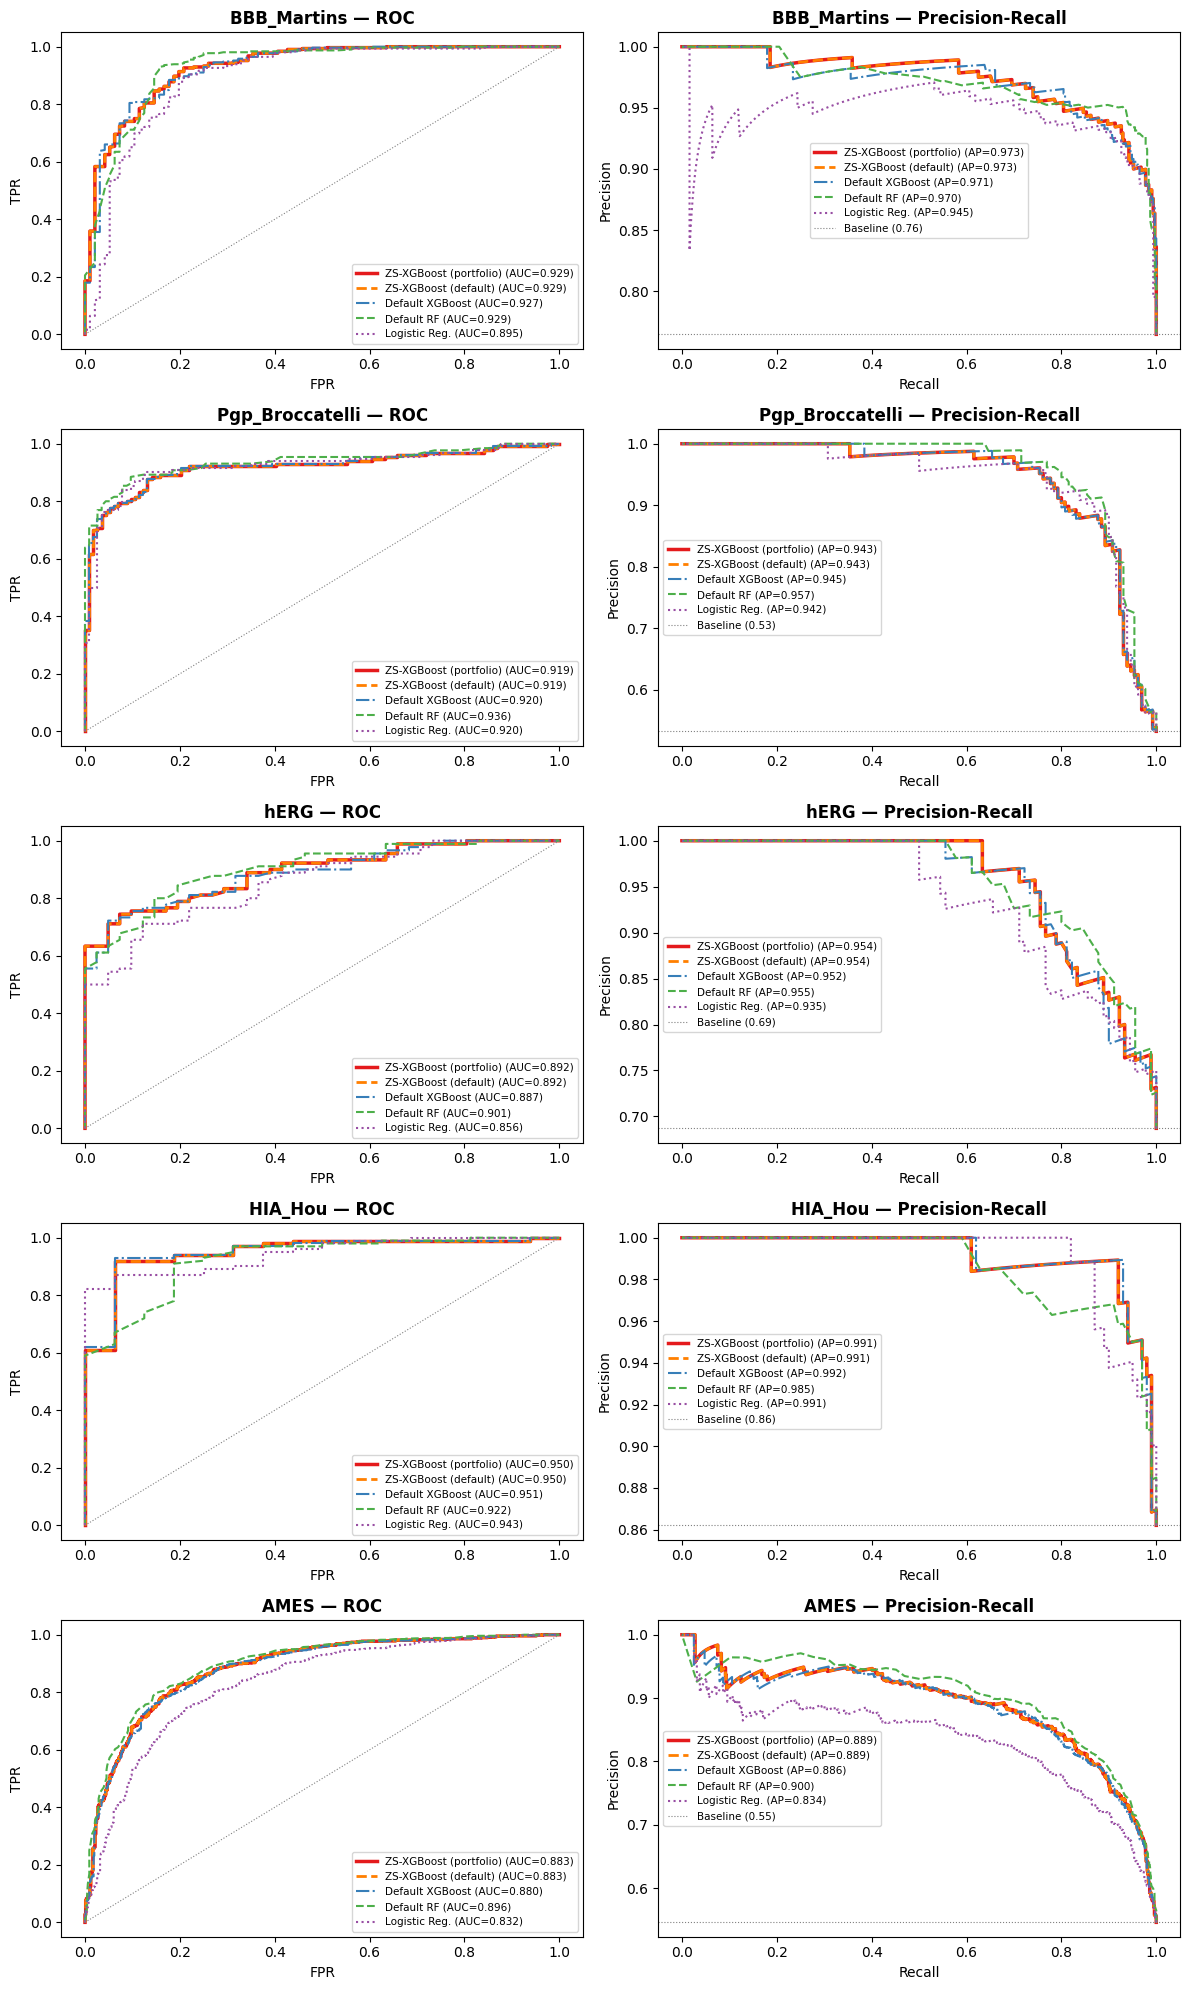

In [6]:
n_ds = len(DATASETS)
fig, axes = plt.subplots(n_ds, 2, figsize=(12, 4 * n_ds))

for row_idx, ds in enumerate(DATASETS):
    name   = ds['name']
    curves = all_curves[name]

    ax_roc = axes[row_idx, 0]
    ax_pr  = axes[row_idx, 1]

    for model_name, style in MODEL_STYLES.items():
        c      = curves[model_name]
        row_df = results_df[(results_df['Dataset'] == name) &
                            (results_df['Model'] == model_name)].iloc[0]
        auc_label = f"{model_name} (AUC={row_df['ROC-AUC']:.3f})"
        ap_label  = f"{model_name} (AP={row_df['PR-AUC']:.3f})"

        ax_roc.plot(c['fpr'], c['tpr'], label=auc_label, **style)
        ax_pr.plot(c['rec'], c['prec'], label=ap_label,  **style)

    ax_roc.plot([0, 1], [0, 1], color='grey', lw=0.8, linestyle=':')
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'{name} — ROC', fontweight='bold')
    ax_roc.legend(fontsize=7.5)

    bp = curves[list(curves.keys())[0]]['baseline_pr']
    ax_pr.axhline(bp, color='grey', lw=0.8, linestyle=':', label=f'Baseline ({bp:.2f})')
    ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'{name} — Precision-Recall', fontweight='bold')
    ax_pr.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig("../results/benchmark_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary table and mean rank

In [7]:
# ROC-AUC table
pivot_roc = results_df.pivot(index='Dataset', columns='Model', values='ROC-AUC').loc[ds_order, col_order]
pivot_pr  = results_df.pivot(index='Dataset', columns='Model', values='PR-AUC').loc[ds_order, col_order]

print("ROC-AUC")
display(pivot_roc.style.background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0).format("{:.4f}"))
print("\nPR-AUC")
display(pivot_pr.style.background_gradient(cmap='RdYlGn', vmin=0.0, vmax=1.0).format("{:.4f}"))

# Mean rank (lower = better)
for metric, pivot in [('ROC-AUC', pivot_roc), ('PR-AUC', pivot_pr)]:
    ranks = pivot.rank(axis=1, ascending=False)
    mean_ranks = ranks.mean().sort_values()
    print(f"\nMean rank by {metric} (lower = better):")
    for model, rank in mean_ranks.items():
        print(f"  {model:22s}: {rank:.2f}")

ROC-AUC


Model,ZS-XGBoost (portfolio),ZS-XGBoost (default),Default XGBoost,Default RF,Logistic Reg.
Dataset,,,,,
BBB_Martins,0.9293,0.9293,0.9266,0.9290,0.8947
Pgp_Broccatelli,0.9188,0.9188,0.9204,0.9358,0.9204
hERG,0.8919,0.8919,0.8873,0.9015,0.8556
HIA_Hou,0.9500,0.9500,0.9506,0.9225,0.9431
AMES,0.8829,0.8829,0.8805,0.8962,0.8318



PR-AUC


Model,ZS-XGBoost (portfolio),ZS-XGBoost (default),Default XGBoost,Default RF,Logistic Reg.
Dataset,,,,,
BBB_Martins,0.9734,0.9734,0.9710,0.9703,0.9451
Pgp_Broccatelli,0.9433,0.9433,0.9448,0.9568,0.9415
hERG,0.9543,0.9543,0.9520,0.9553,0.9346
HIA_Hou,0.9913,0.9913,0.9915,0.9854,0.9910
AMES,0.8889,0.8889,0.8857,0.9002,0.8339



Mean rank by ROC-AUC (lower = better):
  Default RF            : 2.20
  ZS-XGBoost (portfolio): 2.70
  ZS-XGBoost (default)  : 2.70
  Default XGBoost       : 3.20
  Logistic Reg.         : 4.20

Mean rank by PR-AUC (lower = better):
  Default RF            : 2.40
  ZS-XGBoost (portfolio): 2.50
  ZS-XGBoost (default)  : 2.50
  Default XGBoost       : 2.80
  Logistic Reg.         : 4.80


## 6. Bar chart comparison

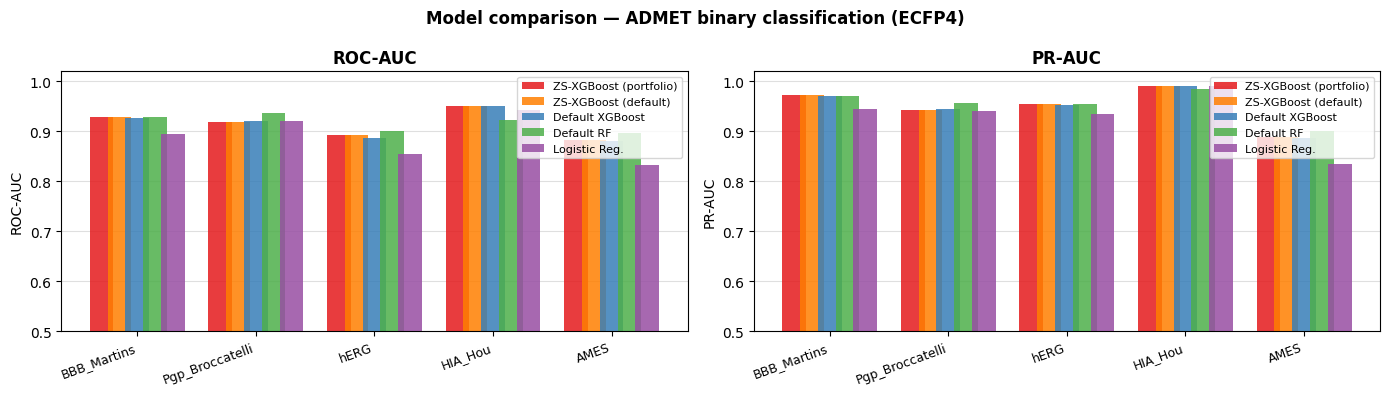

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = [MODEL_STYLES[m]['color'] for m in col_order]
x = np.arange(len(ds_order))
width = 0.2
offsets = np.linspace(-1.5, 1.5, len(col_order)) * width

for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    pivot = results_df.pivot(index='Dataset', columns='Model', values=metric).loc[ds_order, col_order]
    for j, (model, color, offset) in enumerate(zip(col_order, colors, offsets)):
        ax.bar(x + offset, pivot[model], width, label=model, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(ds_order, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.5, 1.02)
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.suptitle("Model comparison — ADMET binary classification (ECFP4)", fontweight='bold')
plt.tight_layout()
plt.savefig("../results/benchmark_bars.png", dpi=150, bbox_inches='tight')
plt.show()